Dataset loaded successfully!
Simulated Stock Data (first 5 rows):


,Open,High,Low,Close,Volume
Date,,,,,
2023-01-01,103.745401,106.783125,101.802015,102.397727,388249
2023-01-02,109.507143,110.359764,108.150398,109.726217,175766
2023-01-03,107.319939,107.645197,103.176252,106.576159,144262
2023-01-04,105.986585,110.731013,104.202818,107.866945,487261
2023-01-05,101.560186,106.388347,100.155514,104.960823,385920


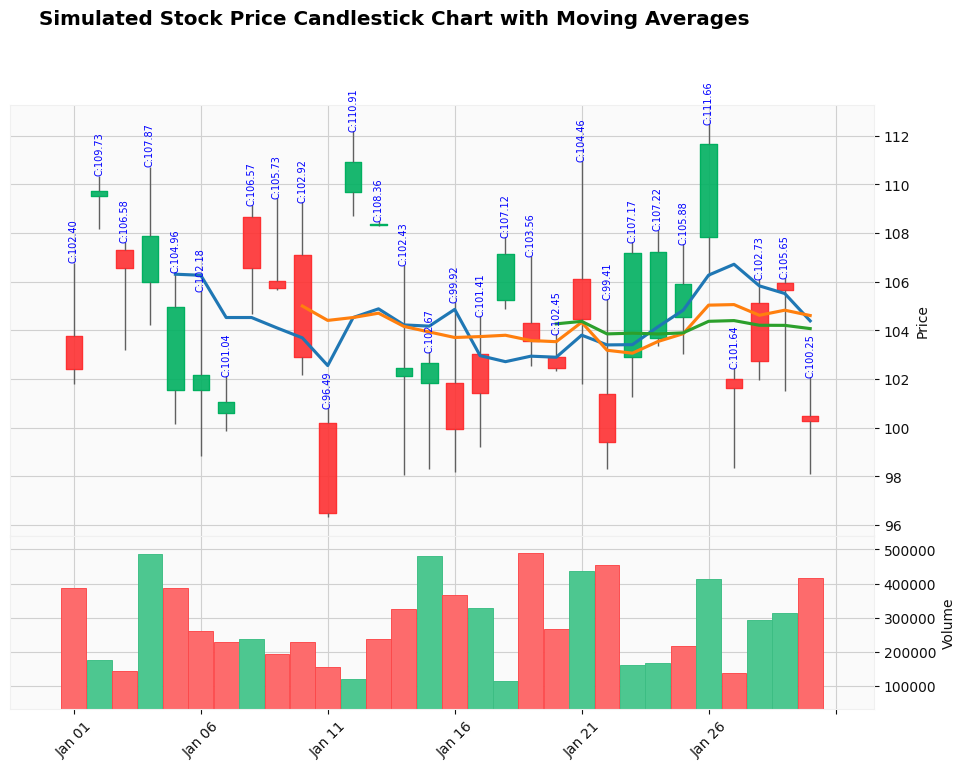

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('dataset.csv')

print("Dataset loaded successfully!")
df.head()

#####################################################################

# --- 1. Simulate Stock Market Data (OHLCV) ---
# Let's create daily data for a few weeks
dates = pd.date_range('2023-01-01', periods=30, freq='D')

# Simulate Open, High, Low, Close prices
np.random.seed(42) # for reproducibility

open_prices = np.random.uniform(100, 110, size=len(dates))

# Ensure High is >= Open, Low is <= Open, and Close is within High/Low
high_prices = open_prices + np.random.uniform(0, 5, size=len(dates))
low_prices = open_prices - np.random.uniform(0, 5, size=len(dates))
close_prices = np.array([np.random.uniform(low, high) for low, high in zip(low_prices, high_prices)])

# Simulate Volume
volume = np.random.randint(100000, 500000, size=len(dates))

# Create a DataFrame
df_candlestick = pd.DataFrame({
    'Open': open_prices,
    'High': high_prices,
    'Low': low_prices,
    'Close': close_prices,
    'Volume': volume
}, index=dates)

# Make sure index is DatetimeIndex
df_candlestick.index.name = 'Date'

print("Simulated Stock Data (first 5 rows):")
display(df_candlestick.head())


#####################################################################
# --- 2. Plotting the Candlestick Chart ---

# Create the candlestick plot
# type='candle' for candlestick chart
# mav=(2, 5, 10) to add Moving Averages (optional)
# volume=True to show volume subplot

fig, axes = mpf.plot(df_candlestick,
                     type='candle',
                     style='yahoo',
                     title='Simulated Stock Price Candlestick Chart with Moving Averages',
                     ylabel='Price',
                     ylabel_lower='Volume',
                     volume=True,
                     mav=(5, 10, 20), # Added Moving Averages: 5-day, 10-day, 20-day
                     returnfig=True,
                     figscale=1.5)

# Add specific price labels to the main chart (price axis)
ax = axes[0] # The main price subplot
for i, (date, row) in enumerate(df_candlestick.iterrows()):
    # Display Close price for each day (adjust position as needed)
    ax.text(i, row['High'], f"C:{row['Close']:.2f}",
            ha='center', va='bottom', fontsize=7, color='blue', rotation=90)
    # Optionally display Open, High, Low as well
    # ax.text(i, row['Open'], f"O:{row['Open']:.2f}", ha='center', va='top', fontsize=6, color='green')
    # ax.text(i, row['Low'], f"L:{row['Low']:.2f}", ha='center', va='top', fontsize=6, color='red')

plt.show()
#####################################################################


In [ ]:
import pandas as pd
import os

def display_csv_dataset():
    print("=== CSV Dataset Viewer ===")
    
    # Accept the file path from the user
    file_path = input("Enter the path to your CSV file (e.g., data.csv): ").strip()
    
    # Check if the file actually exists
    if os.path.exists(file_path):
        try:
            # Read the file
            df = pd.read_csv(file_path, on_bad_lines='skip')  # Skip bad lines to avoid errors
            df.show = True  # Disable truncated display for better readability

            # Display contents
            print("\n--- Dataset Overview ---")
            print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
            print("\n--- First 5 Rows of Data ---")
            print(df.head())  # Displays a clean horizontal preview table
            
        except Exception as e:
            print(f"Error reading file: {e}")
    else:
        print("Error: File not found. Please check the path and try again.")

if __name__ == "__main__":
    display_csv_dataset()

=== CSV Dataset Viewer ===

--- Dataset Overview ---
Rows: 8049 | Columns: 12

--- First 5 Rows of Data ---
  Nasdaq Traded Symbol                                      Security Name  \
0             Y      A            Agilent Technologies, Inc. Common Stock   
1             Y     AA                    Alcoa Corporation Common Stock    
2             Y   AAAU                       Perth Mint Physical Gold ETF   
3             Y   AACG  ATA Creativity Global - American Depositary Sh...   
4             Y   AADR                AdvisorShares Dorsey Wright ADR ETF   

  Listing Exchange Market Category ETF  Round Lot Size Test Issue  \
0                N                   N           100.0          N   
1                N                   N           100.0          N   
2                P                   Y           100.0          N   
3                Q               G   N           100.0          N   
4                P                   Y           100.0          N   

  Financial St

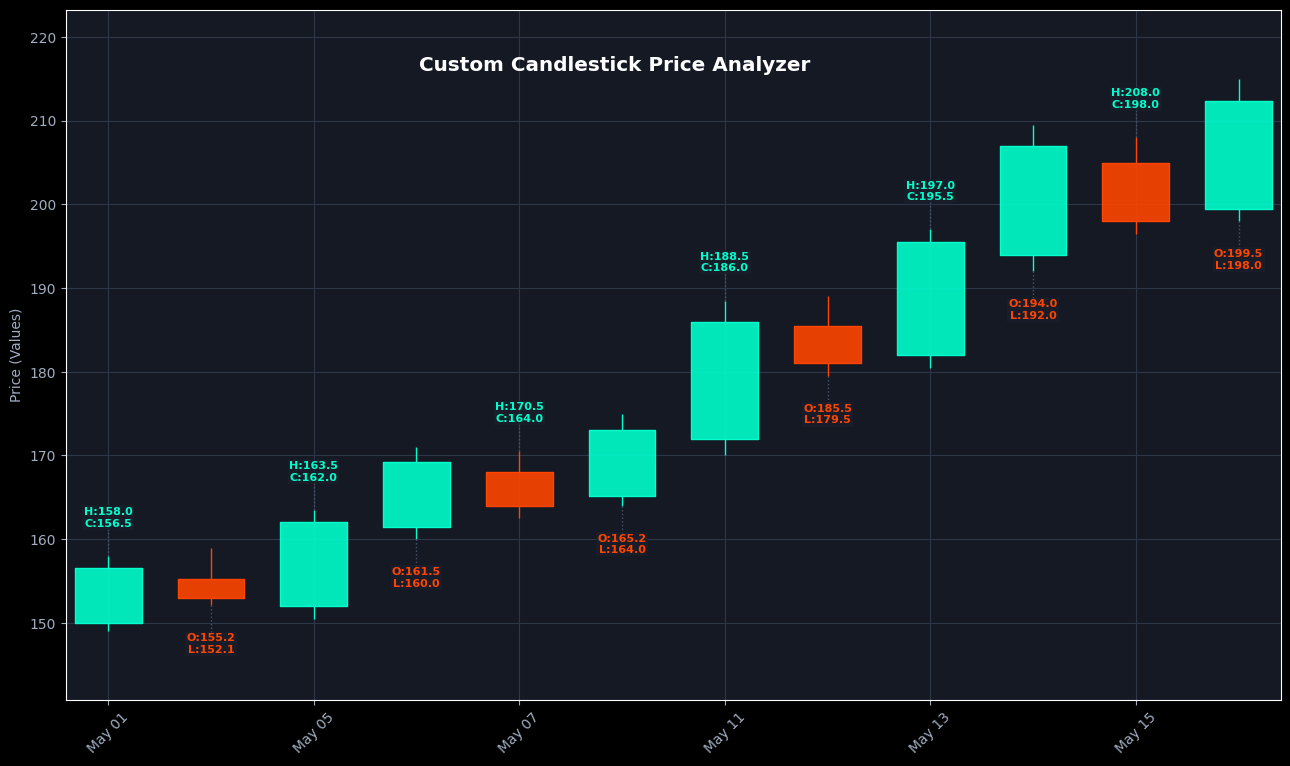

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

def plot_user_candlestick(file_path=None):
    # 1. Load the User's Dataset or fallback to a sample if empty
    if file_path:
        try:
            # Assumes a CSV with columns: Date, Open, High, Low, Close
            df = pd.read_csv(r"D:\Downloads\symbols_valid_meta.csv")
            df['Date'] = pd.to_datetime(df['Date'])
            df.set_index('Date', inplace=True)
        except Exception as e:
            print(f"Error loading file: {e}. Loading fallback sample data instead.")
            df = get_sample_data()
    else:
        df = get_sample_data()

    # 2. Replicate the Image Style (Dark Background + Glowing Cyber Colors)
    custom_colors = mpf.make_marketcolors(
        up='#00ffcc',          # Glowing neon green/cyan for upward days
        down='#ff4500',        # Vibrant neon orange/red for downward days
        edge='inherit',
        wick='inherit',
        volume='inherit'
    )

    dark_dashboard_style = mpf.make_mpf_style(
        base_mpf_style='nightclouds', # High-contrast dark palette base
        marketcolors=custom_colors,
        gridcolor='#2d3748',          # Subtle grid lines like the image background
        gridstyle='solid',
        facecolor='#141923'           # Deep matte dark canvas color
    )

    # 3. Initialize the Plot Canvas
    # returnfig=True lets us modify text layouts using core matplotlib commands
    fig, axlist = mpf.plot(
        df, 
        type='candle', 
        style=dark_dashboard_style,
        title="\nCustom Candlestick Price Analyzer",
        ylabel="Price (Values)",
        returnfig=True,
        figsize=(14, 8),
        tight_layout=True
    )

    ax = axlist[0]
    
    # Custom color adjustments for labels to stand out on dark canvas
    ax.title.set_color('#ffffff')
    ax.yaxis.label.set_color('#a0aec0')
    ax.tick_params(colors='#a0aec0', which='both')

    # Calculate dynamic spacing offsets based on the stock price range
    price_range = df['High'].max() - df['Low'].min()
    offset_base = price_range * 0.05  # 5% of price spread used as a buffer line

    # 4. Show Values at Every Point (Staggered to prevent overlap clutter)
    for i in range(len(df)):
        row = df.iloc[i]
        
        # Stagger text heights alternately up and down so neighboring words don't crash
        if i % 2 == 0:
            # Even indexes: Plot values ABOVE the High Wick
            text_y = row['High'] + offset_base
            label_text = f"H:{row['High']:.1f}\nC:{row['Close']:.1f}"
            text_color = '#00ffcc'
            va_dir = 'bottom'
            
            # Draw a subtle line connecting the text label directly down to the wick point
            ax.plot([i, i], [row['High'], text_y], color='#4a5568', linestyle=':', linewidth=1)
        else:
            # Odd matrix indexes: Plot values BELOW the Low Wick
            text_y = row['Low'] - offset_base
            label_text = f"O:{row['Open']:.1f}\nL:{row['Low']:.1f}"
            text_color = '#ff4500'
            va_dir = 'top'
            
            # Draw a subtle line connecting the text label directly up to the wick point
            ax.plot([i, i], [row['Low'], text_y], color='#4a5568', linestyle=':', linewidth=1)

        # Place the physical text numbers on the canvas chart
        ax.text(i, text_y, label_text, 
                ha='center', 
                va=va_dir, 
                fontsize=8, 
                color=text_color, 
                fontweight='bold',
                bbox=dict(facecolor='#1a202c', alpha=0.7, edgecolor='none', pad=1))

    # Adjust limits to fit the newly drawn pointer text elements cleanly
    ax.set_ylim(df['Low'].min() - (offset_base * 2.5), df['High'].max() + (offset_base * 2.5))

    # 5. Render the Dashboard Window
    plt.show()

def get_sample_data():
    """Generates an internal fallback sample dataset matching the trend in your image."""
    import numpy as np
    dates = pd.date_range(start='2026-05-01', periods=12, freq='B')
    # Mimicking an aggressive upward breakout rally structure
    opens =  [150.0, 155.2, 152.0, 161.5, 168.0, 165.2, 172.0, 185.5, 182.0, 194.0, 205.0, 199.5]
    closes = [156.5, 153.0, 162.0, 169.2, 164.0, 173.1, 186.0, 181.0, 195.5, 207.0, 198.0, 212.4]
    highs =  [158.0, 159.0, 163.5, 171.0, 170.5, 175.0, 188.5, 189.0, 197.0, 209.5, 208.0, 215.0]
    lows =   [149.0, 152.1, 150.5, 160.0, 162.5, 164.0, 170.0, 179.5, 180.5, 192.0, 196.5, 198.0]
    
    return pd.DataFrame({'Open': opens, 'High': highs, 'Low': lows, 'Close': closes}, index=dates)

if __name__ == "__main__":
    # --- TO USE YOUR OWN DATA ---
    # Save your data as 'my_stocks.csv' making sure it has column headers: Date, Open, High, Low, Close
    # Then pass the path name into the function below like: plot_user_candlestick('my_stocks.csv')
    plot_user_candlestick()

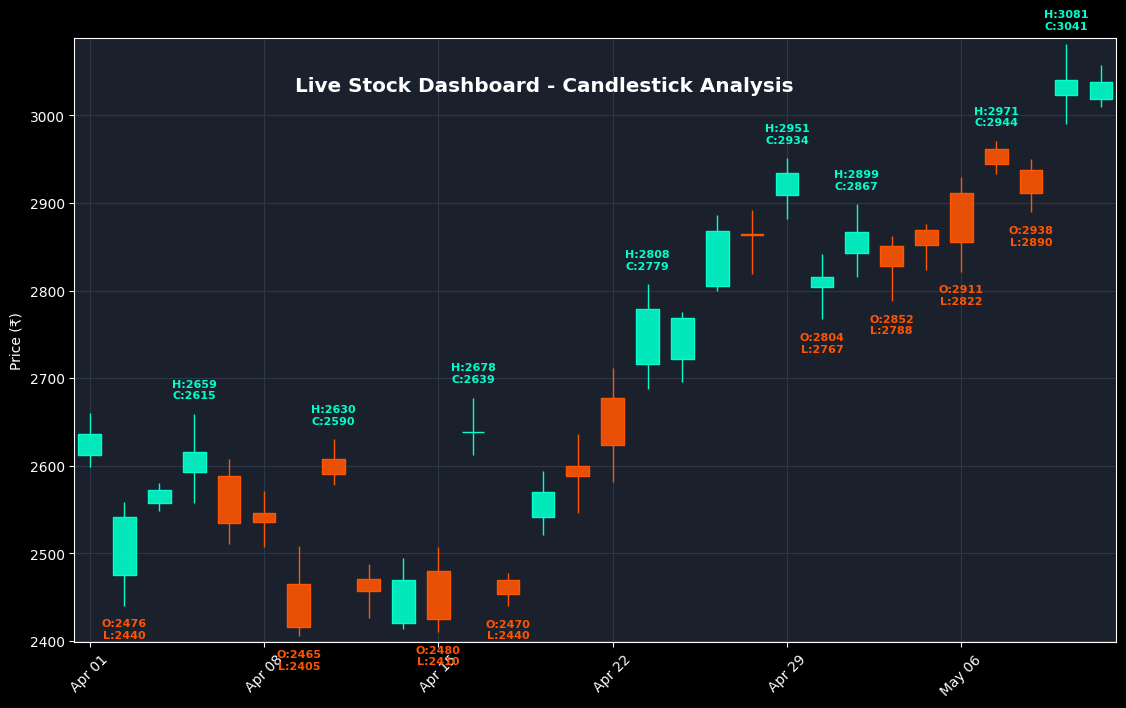

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

# 1. Generate 30 Days of Mock Stock Data (Simulating a highly volatile trend like the image)
np.random.seed(10)
dates = pd.date_range(start='2026-04-01', periods=30, freq='B')

# Generate a random walk for prices
base_price = 2500
prices = []
for _ in range(30):
    base_price += np.random.uniform(-120, 150)
    prices.append(base_price)

opens = [p + np.random.uniform(-40, 40) for p in prices]
closes = [o + np.random.uniform(-60, 80) for o in opens]
highs = [max(o, c) + np.random.uniform(5, 45) for o, c in zip(opens, closes)]
lows = [min(o, c) - np.random.uniform(5, 45) for o, c in zip(opens, closes)]

df = pd.DataFrame({'Open': opens, 'High': highs, 'Low': lows, 'Close': closes}, index=dates)

# 2. Replicate the Image Aesthetic (Dark Theme with Glowing Green & Orange/Red)
# Creating a custom market colors object
custom_colors = mpf.make_marketcolors(
    up='#00ffcc',          # Glowing Cyan/Green for up candles
    down='#ff5500',        # Vibrant Orange/Red for down candles
    edge='inherit',
    wick='inherit',
    volume='inherit'
)

# Merging colors into a dark background style template
dark_dashboard_style = mpf.make_mpf_style(
    base_mpf_style='nightclouds', # Gives us the dark slate background
    marketcolors=custom_colors,
    gridcolor='#2d3748',
    gridstyle='solid',
    facecolor='#1a202c'           # Deep dark background matching the picture
)

# 3. Initialize the Plot
fig, axlist = mpf.plot(
    df, 
    type='candle', 
    style=dark_dashboard_style,
    title="\nLive Stock Dashboard - Candlestick Analysis",
    ylabel="Price (₹)",
    returnfig=True,
    figsize=(12, 7),
    tight_layout=True
)

ax = axlist[0]
ax.title.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white', which='both')

# 4. Display Values at Critical Structural Points (Peaks & Valleys)
# This prevents text overlap while keeping data transparent
for i in range(1, len(df) - 1):
    current_high = df['High'].iloc[i]
    current_low = df['Low'].iloc[i]
    
    # Check if this point is a local Peak (High is greater than yesterday and tomorrow)
    is_peak = current_high > df['High'].iloc[i-1] and current_high > df['High'].iloc[i+1]
    # Check if this point is a local Valley (Low is lesser than yesterday and tomorrow)
    is_valley = current_low < df['Low'].iloc[i-1] and current_low < df['Low'].iloc[i+1]
    
    row = df.iloc[i]
    if is_peak:
        # Print High and Close on peaks
        ax.text(i, row['High'] + 15, f"H:{row['High']:.0f}\nC:{row['Close']:.0f}", 
                ha='center', va='bottom', fontsize=8, color='#00ffcc', fontweight='bold')
    elif is_valley:
        # Print Low and Open on valleys
        ax.text(i, row['Low'] - 15, f"O:{row['Open']:.0f}\nL:{row['Low']:.0f}", 
                ha='center', va='top', fontsize=8, color='#ff5500', fontweight='bold')

# 5. Bring up the canvas view
plt.show()

Chart saved → tsla_candlestick.png


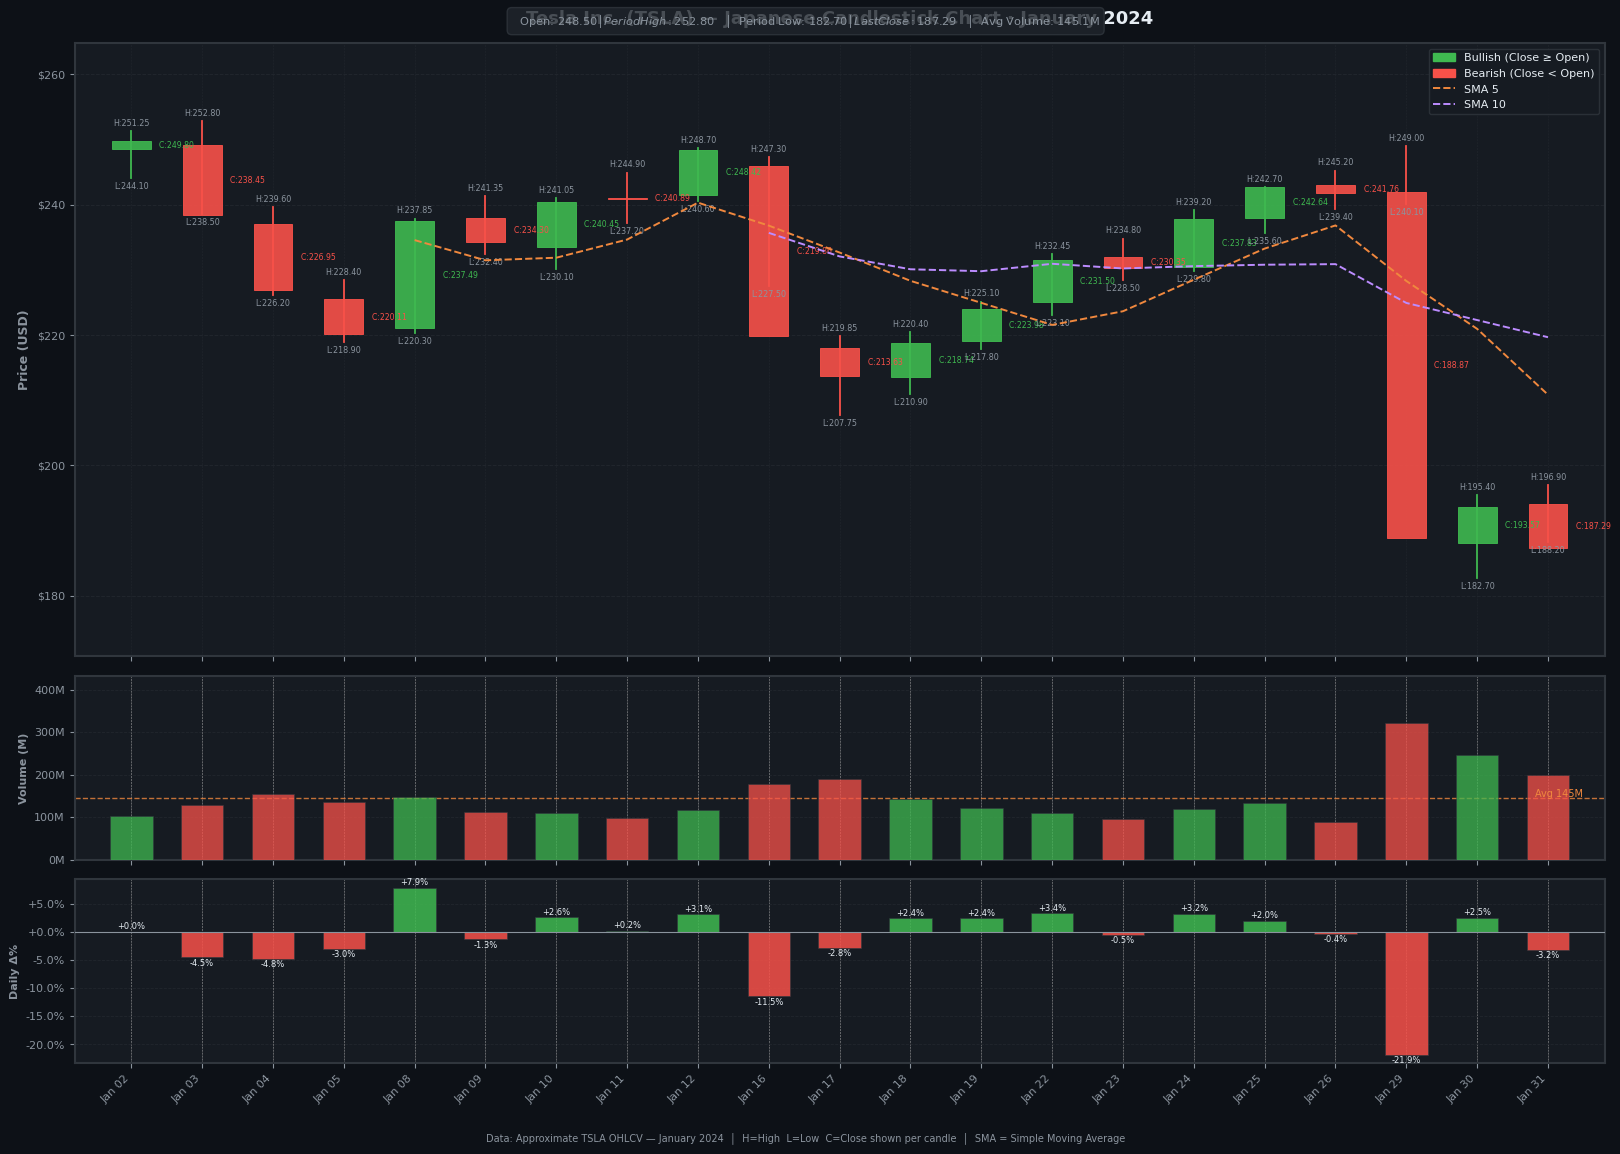

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import numpy as np

# ── Tesla Inc. (TSLA) – Daily OHLCV Data, January 2024 ────────────────────
# Columns: Date, Open, High, Low, Close, Volume (approx. real market data)

data = [
    # Date           Open     High     Low      Close    Volume(M)
    ("Jan 02",      248.50,  251.25,  244.10,  249.80,  103.2),
    ("Jan 03",      249.20,  252.80,  238.50,  238.45,  128.5),
    ("Jan 04",      237.00,  239.60,  226.20,  226.95,  155.3),
    ("Jan 05",      225.50,  228.40,  218.90,  220.11,  134.7),
    ("Jan 08",      221.00,  237.85,  220.30,  237.49,  147.6),
    ("Jan 09",      238.00,  241.35,  232.40,  234.30,  112.4),
    ("Jan 10",      233.50,  241.05,  230.10,  240.45,  108.9),
    ("Jan 11",      241.00,  244.90,  237.20,  240.89,   98.3),
    ("Jan 12",      241.50,  248.70,  240.60,  248.42,  116.8),
    ("Jan 16",      246.00,  247.30,  227.50,  219.86,  178.4),
    ("Jan 17",      218.00,  219.85,  207.75,  213.63,  189.2),
    ("Jan 18",      213.50,  220.40,  210.90,  218.74,  143.6),
    ("Jan 19",      219.00,  225.10,  217.80,  223.98,  121.3),
    ("Jan 22",      225.00,  232.45,  223.10,  231.50,  109.7),
    ("Jan 23",      232.00,  234.80,  228.50,  230.35,   95.4),
    ("Jan 24",      230.50,  239.20,  229.80,  237.83,  118.6),
    ("Jan 25",      238.00,  242.70,  235.60,  242.64,  132.1),
    ("Jan 26",      243.00,  245.20,  239.40,  241.76,   89.5),
    ("Jan 29",      242.00,  249.00,  240.10,  188.87,  320.4),  # big drop day
    ("Jan 30",      188.00,  195.40,  182.70,  193.57,  245.8),
    ("Jan 31",      194.00,  196.90,  188.20,  187.29,  198.3),
]

dates  = [d[0] for d in data]
opens  = np.array([d[1] for d in data])
highs  = np.array([d[2] for d in data])
lows   = np.array([d[3] for d in data])
closes = np.array([d[4] for d in data])
vols   = np.array([d[5] for d in data])

x      = np.arange(len(dates))
bull   = closes >= opens          # True = green candle
colors = ["#3fb950" if b else "#f85149" for b in bull]

# ── Layout: 3 rows (candlestick | volume | indicators) ─────────────────────
fig = plt.figure(figsize=(17, 12))
fig.patch.set_facecolor("#0d1117")

gs = gridspec.GridSpec(3, 1, figure=fig,
                       height_ratios=[4, 1.2, 1.2],
                       hspace=0.06,
                       left=0.07, right=0.97,
                       top=0.93, bottom=0.08)

ax_c  = fig.add_subplot(gs[0])   # candlestick
ax_v  = fig.add_subplot(gs[1], sharex=ax_c)  # volume
ax_ma = fig.add_subplot(gs[2], sharex=ax_c)  # RSI-style momentum

for ax in [ax_c, ax_v, ax_ma]:
    ax.set_facecolor("#161b22")
    for sp in ax.spines.values():
        sp.set_edgecolor("#30363d")
    ax.tick_params(colors="#8b949e", labelsize=8)

# ══════════════════════════════════════════════════════════════════════════
# PANEL 1 — Candlestick chart
# ══════════════════════════════════════════════════════════════════════════
W = 0.55   # candle body width

for i in range(len(x)):
    clr = colors[i]
    o, h, l, c = opens[i], highs[i], lows[i], closes[i]

    # Wick (high-low)
    ax_c.plot([x[i], x[i]], [l, h],
              color=clr, linewidth=1.3, zorder=3)

    # Body (open-close rectangle)
    body_bot = min(o, c)
    body_h   = abs(c - o) if abs(c - o) > 0.1 else 0.1   # doji guard
    rect = mpatches.FancyBboxPatch(
        (x[i] - W / 2, body_bot), W, body_h,
        linewidth=0.7, edgecolor=clr,
        facecolor=clr if c >= o else clr,
        alpha=0.9, zorder=4,
        boxstyle="square,pad=0"
    )
    ax_c.add_patch(rect)

    # ── Price labels (OHLC) shown above/below each candle ─────────────
    label_gap = (highs.max() - lows.min()) * 0.008
    ax_c.text(x[i], h + label_gap,
              f"H:{h:.2f}",
              ha="center", va="bottom", fontsize=5.8,
              color="#8b949e", zorder=5)
    ax_c.text(x[i], l - label_gap,
              f"L:{l:.2f}",
              ha="center", va="top", fontsize=5.8,
              color="#8b949e", zorder=5)
    # Close price in candle colour
    side = 1 if c >= o else -1
    ax_c.text(x[i] + W / 2 + 0.05, (o + c) / 2,
              f"  C:{c:.2f}",
              ha="left", va="center", fontsize=5.6,
              color=clr, zorder=5)

# 5-day & 10-day Simple Moving Averages
def sma(arr, n):
    return np.array([np.nan if i < n - 1
                     else arr[i-n+1:i+1].mean()
                     for i in range(len(arr))])

sma5  = sma(closes, 5)
sma10 = sma(closes, 10)

ax_c.plot(x, sma5,  color="#f0883e", linewidth=1.4,
          linestyle="--", label="SMA 5",  zorder=6)
ax_c.plot(x, sma10, color="#bc8cff", linewidth=1.4,
          linestyle="--", label="SMA 10", zorder=6)

# Gridlines
ax_c.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.0f}"))
ax_c.set_ylim(lows.min() - 12, highs.max() + 12)
ax_c.set_xlim(-0.8, len(x) - 0.2)
ax_c.grid(axis="y", color="#21262d", linewidth=0.7, zorder=0)
ax_c.grid(axis="x", color="#21262d", linewidth=0.4, zorder=0)

ax_c.set_title("Tesla Inc. (TSLA) — Japanese Candlestick Chart · January 2024",
               fontsize=13, fontweight="bold", color="#e6edf3", pad=14)
ax_c.set_ylabel("Price (USD)", fontsize=9, color="#8b949e")

# Legend
bull_p = mpatches.Patch(color="#3fb950", label="Bullish (Close ≥ Open)")
bear_p = mpatches.Patch(color="#f85149", label="Bearish (Close < Open)")
sma5_l = mlines.Line2D([], [], color="#f0883e", linestyle="--",
                        linewidth=1.4, label="SMA 5")
sma10_l= mlines.Line2D([], [], color="#bc8cff", linestyle="--",
                        linewidth=1.4, label="SMA 10")
ax_c.legend(handles=[bull_p, bear_p, sma5_l, sma10_l],
            loc="upper right", fontsize=8,
            facecolor="#161b22", edgecolor="#30363d",
            labelcolor="#e6edf3")

plt.setp(ax_c.get_xticklabels(), visible=False)

# ══════════════════════════════════════════════════════════════════════════
# PANEL 2 — Volume bars
# ══════════════════════════════════════════════════════════════════════════
ax_v.bar(x, vols, color=colors, alpha=0.75,
         edgecolor="#30363d", linewidth=0.5, width=0.6, zorder=3)

avg_vol = vols.mean()
ax_v.axhline(avg_vol, color="#f0883e", linewidth=1,
             linestyle="--", alpha=0.8)
ax_v.text(len(x) - 0.5, avg_vol + 3,
          f"Avg {avg_vol:.0f}M",
          ha="right", fontsize=7, color="#f0883e")

ax_v.set_ylabel("Volume (M)", fontsize=8, color="#8b949e")
ax_v.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}M"))
ax_v.grid(axis="y", color="#21262d", linewidth=0.6, zorder=0)
ax_v.set_ylim(0, vols.max() * 1.35)
plt.setp(ax_v.get_xticklabels(), visible=False)

# ══════════════════════════════════════════════════════════════════════════
# PANEL 3 — Daily Price Change % (momentum)
# ══════════════════════════════════════════════════════════════════════════
pct_change = np.zeros(len(closes))
pct_change[1:] = (closes[1:] - closes[:-1]) / closes[:-1] * 100
bar_colors_m = ["#3fb950" if v >= 0 else "#f85149" for v in pct_change]

ax_ma.bar(x, pct_change, color=bar_colors_m, alpha=0.85,
          edgecolor="#30363d", linewidth=0.5, width=0.6, zorder=3)
ax_ma.axhline(0, color="#8b949e", linewidth=0.8, zorder=4)

for i, v in enumerate(pct_change):
    ax_ma.text(x[i], v + (0.15 if v >= 0 else -0.15),
               f"{v:+.1f}%",
               ha="center",
               va="bottom" if v >= 0 else "top",
               fontsize=6, color="#e6edf3", zorder=5)

ax_ma.set_ylabel("Daily Δ%", fontsize=8, color="#8b949e")
ax_ma.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.1f}%"))
ax_ma.grid(axis="y", color="#21262d", linewidth=0.6, zorder=0)

ax_ma.set_xticks(x)
ax_ma.set_xticklabels(dates, rotation=45, ha="right",
                      fontsize=8, color="#8b949e")

# ── OHLC summary table below title ──────────────────────────────────────
summary = (
    f"  Open: ${opens[0]:.2f}   "
    f"│  Period High: ${highs.max():.2f}   "
    f"│  Period Low: ${lows.min():.2f}   "
    f"│  Last Close: ${closes[-1]:.2f}   "
    f"│  Avg Volume: {avg_vol:.1f}M"
)
fig.text(0.5, 0.945, summary,
         ha="center", fontsize=8.2, color="#8b949e",
         bbox=dict(boxstyle="round,pad=0.4",
                   facecolor="#21262d", edgecolor="#30363d", alpha=0.8))

# ── Footnote ────────────────────────────────────────────────────────────
fig.text(0.5, 0.015,
         "Data: Approximate TSLA OHLCV — January 2024  "
         "│  H=High  L=Low  C=Close shown per candle  "
         "│  SMA = Simple Moving Average",
         ha="center", fontsize=7, color="#8b949e")

plt.savefig("D:\\Downloads\\tsla_candlestick.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Chart saved → tsla_candlestick.png")
plt.show()

C:\Users\Avishek\AppData\Local\Temp\ipykernel_29624\986678838.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


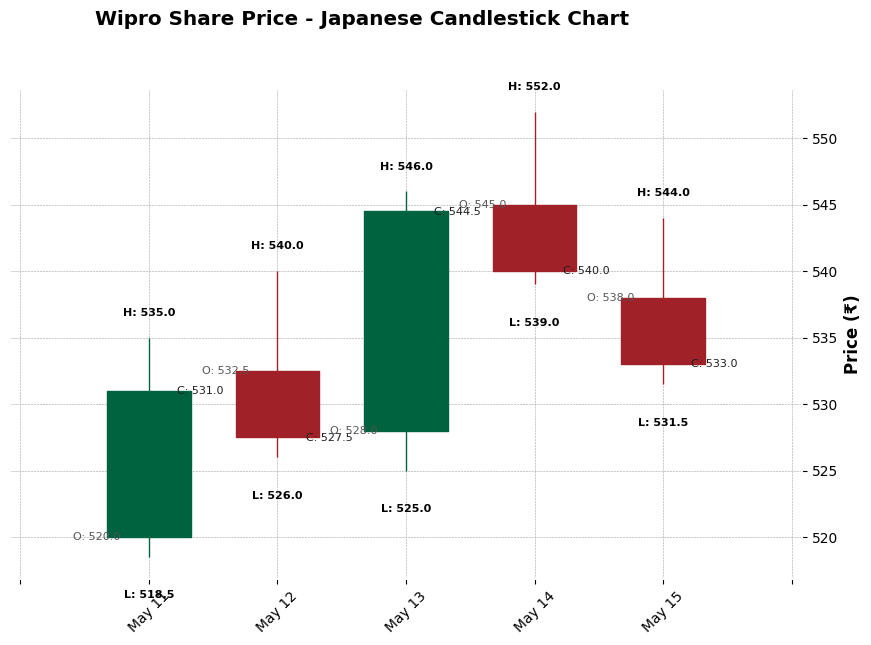

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

# 1. Create Mock OHLC Data for an Indian Stock (e.g., WIPRO over 5 days)
# Candlestick data MUST have a DatetimeIndex
data = {
    'Date': ['2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15'],
    'Open':  [520.00, 532.50, 528.00, 545.00, 538.00],
    'High':  [535.00, 540.00, 546.00, 552.00, 544.00],
    'Low':   [518.50, 526.00, 525.00, 539.00, 531.50],
    'Close': [531.00, 527.50, 544.50, 540.00, 533.00],
    'Volume':[10000, 12000, 15000, 11000, 9500]
}

df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 2. Setup the Core Plot using mplfinance
# we use returnfig=True so we can manually add text labels using traditional matplotlib hooks
fig, axlist = mpf.plot(
    df, 
    type='candle', 
    style='charles',     # Traditional green (up) and red (down) style
    title="Wipro Share Price - Japanese Candlestick Chart",
    ylabel="Price (₹)",
    returnfig=True,
    figsize=(11, 7)
)

# Grab the primary axes where the candlesticks are drawn
ax = axlist[0]

# 3. Loop through the data to annotate Open, High, Low, and Close values
# 'i' serves as the horizontal X-coordinate on the plot grid
for i in range(len(df)):
    row = df.iloc[i]
    
    # Text configuration for a clean layout
    # High (placed slightly above the top wick)
    ax.text(i, row['High'] + 1.5, f"H: {row['High']:.1f}", 
            ha='center', va='bottom', fontsize=8, color='black', fontweight='bold')
    
    # Low (placed slightly below the bottom wick)
    ax.text(i, row['Low'] - 2.5, f"L: {row['Low']:.1f}", 
            ha='center', va='top', fontsize=8, color='black', fontweight='bold')
    
    # Close & Open prices (placed to the left and right sides of the candle body)
    ax.text(i - 0.22, row['Open'], f"O: {row['Open']:.1f}", 
            ha='right', va='center', fontsize=8, color='#555555')
    
    ax.text(i + 0.22, row['Close'], f"C: {row['Close']:.1f}", 
            ha='left', va='center', fontsize=8, color='#1e1e1e')

# 4. Final adjustments to layout space
plt.tight_layout()
plt.show()

C:\Users\Avishek\AppData\Local\Temp\ipykernel_5876\270638232.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=df_box, palette='coolwarm')


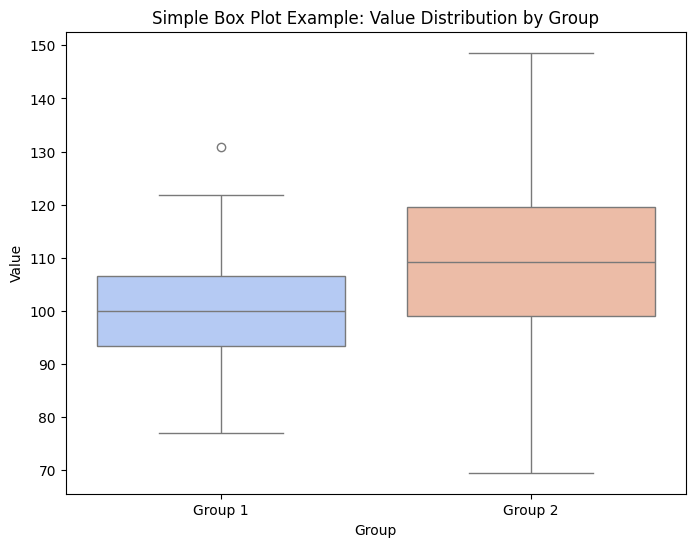

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Generate some example data for a box plot
# Let's create data for two different groups to compare their distributions
data1 = np.random.normal(loc=100, scale=10, size=200) # Group 1 centered around 100
data2 = np.random.normal(loc=110, scale=15, size=200) # Group 2 centered around 110 with more spread

# Combine the data into a pandas DataFrame for easier plotting with seaborn
df_box = pd.DataFrame({
    'Value': np.concatenate([data1, data2]),
    'Group': ['Group 1']*len(data1) + ['Group 2']*len(data2)
})

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='Value', data=df_box, palette='coolwarm')

# Add labels and title
plt.title('Simple Box Plot Example: Value Distribution by Group')
plt.xlabel('Group')
plt.ylabel('Value')

plt.show()

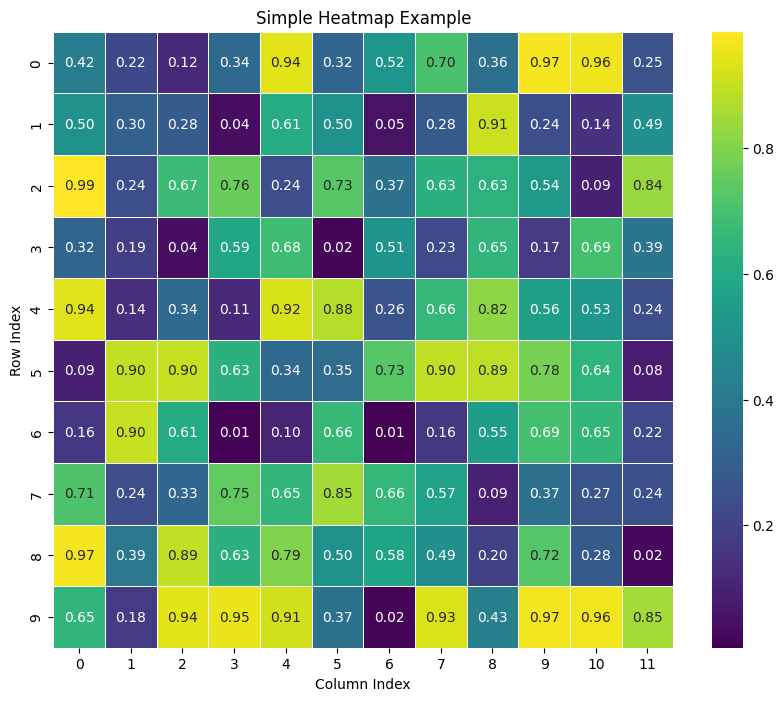

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate some random data for the heatmap
data = np.random.rand(10, 12) # 10 rows, 12 columns

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)

# Add labels and title
plt.title('Simple Heatmap Example')
plt.xlabel('Column Index')
plt.ylabel('Row Index')

plt.show()

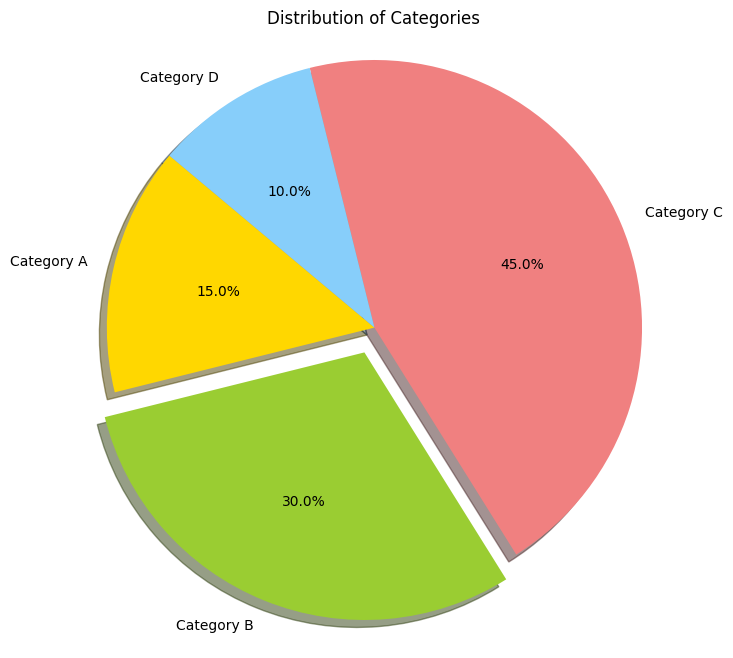

In [26]:
import matplotlib.pyplot as plt

# Data for the pie chart
labels = ['Category A', 'Category B', 'Category C', 'Category D']
sizes = [15, 30, 45, 10] # Proportions for each category
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = (0, 0.1, 0, 0)  # 'explode' the 2nd slice (Category B) a little

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Categories')
plt.show()

Chart saved → car_manufacturer_piechart.png


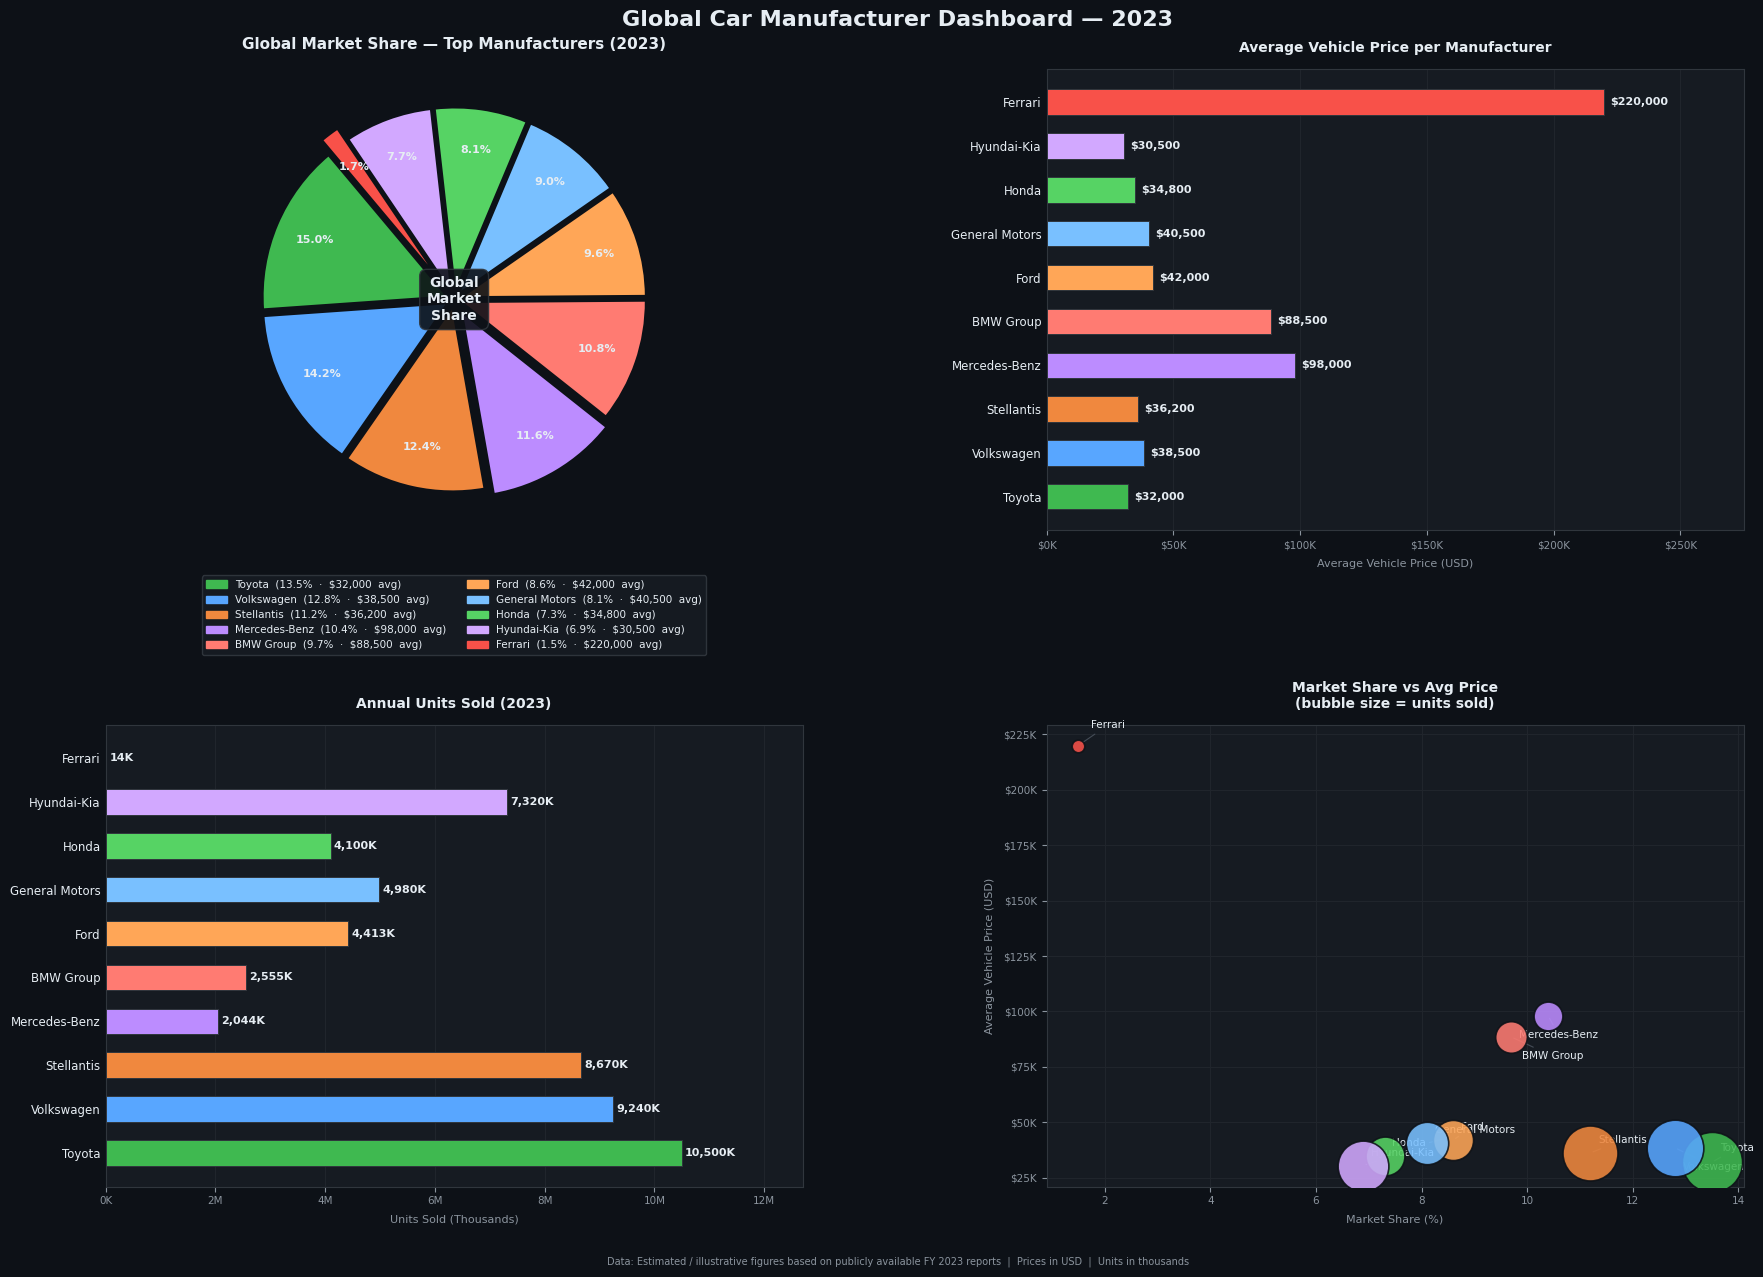

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ── Car Manufacturer Dataset: Global Market Share & Avg Price (2023) ───────

manufacturers = [
    "Toyota", "Volkswagen", "Stellantis", "Mercedes-Benz",
    "BMW Group", "Ford", "General Motors", "Honda",
    "Hyundai-Kia", "Ferrari"
]

# Global revenue share (%) – approximate FY 2023
market_share = [13.5, 12.8, 11.2, 10.4, 9.7, 8.6, 8.1, 7.3, 6.9, 1.5]

# Average vehicle price (USD) per manufacturer
avg_price = [
    32_000,   # Toyota
    38_500,   # Volkswagen
    36_200,   # Stellantis
    98_000,   # Mercedes-Benz
    88_500,   # BMW Group
    42_000,   # Ford
    40_500,   # General Motors
    34_800,   # Honda
    30_500,   # Hyundai-Kia
   220_000,   # Ferrari
]

# Annual units sold (thousands)
units_sold = [10_500, 9_240, 8_670, 2_044, 2_555,
               4_413, 4_980, 4_100, 7_320,    14]

colors = [
    "#3fb950",  # Toyota      – green
    "#58a6ff",  # Volkswagen  – blue
    "#f0883e",  # Stellantis  – orange
    "#bc8cff",  # Mercedes    – purple
    "#ff7b72",  # BMW         – coral
    "#ffa657",  # Ford        – amber
    "#79c0ff",  # GM          – sky
    "#56d364",  # Honda       – lime
    "#d2a8ff",  # Hyundai-Kia – lavender
    "#f85149",  # Ferrari     – red
]

explode = [0.04] * len(manufacturers)
explode[9] = 0.12   # pop Ferrari out more (luxury outlier)
explode[3] = 0.08   # pop Mercedes

# ══════════════════════════════════════════════════════════════════════════
# Figure layout: 2 rows × 2 cols
#   [0,0] Pie chart (main)       [0,1] Horizontal bar – Avg Price
#   [1,0] Horizontal bar – Units [1,1] Scatter – Price vs Share
# ══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor("#0d1117")

gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.42, wspace=0.35,
                       left=0.06, right=0.97,
                       top=0.93, bottom=0.07)

ax_pie  = fig.add_subplot(gs[0, 0])
ax_avgp = fig.add_subplot(gs[0, 1])
ax_unit = fig.add_subplot(gs[1, 0])
ax_scat = fig.add_subplot(gs[1, 1])

for ax in [ax_pie, ax_avgp, ax_unit, ax_scat]:
    ax.set_facecolor("#161b22")

# ══════════════════════════════════════════════════════════════════════════
# [0,0]  PIE CHART – Market Share
# ══════════════════════════════════════════════════════════════════════════
total_share = sum(market_share)

wedges, _, autotexts = ax_pie.pie(
    market_share,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%",
    startangle=130,
    explode=explode,
    colors=colors,
    wedgeprops=dict(linewidth=1.6, edgecolor="#0d1117"),
    pctdistance=0.78,
    shadow=False,
)

for at in autotexts:
    at.set_fontsize(8)
    at.set_fontweight("bold")
    at.set_color("#e6edf3")

# Centre label
ax_pie.text(0, 0, "Global\nMarket\nShare",
            ha="center", va="center",
            fontsize=10, fontweight="bold", color="#e6edf3",
            bbox=dict(boxstyle="round,pad=0.5",
                      facecolor="#0d1117", edgecolor="#30363d", alpha=0.9))

ax_pie.set_title("Global Market Share — Top Manufacturers (2023)",
                 fontsize=11, fontweight="bold", color="#e6edf3", pad=14)

# Legend
legend_handles = [
    mpatches.Patch(color=c,
                   label=f"{m}  ({s:.1f}%  ·  ${p:,}  avg)")
    for m, s, p, c in zip(manufacturers, market_share, avg_price, colors)
]
ax_pie.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    fontsize=7.5,
    facecolor="#161b22",
    edgecolor="#30363d",
    labelcolor="#e6edf3",
    framealpha=0.95,
)

# ══════════════════════════════════════════════════════════════════════════
# [0,1]  HORIZONTAL BAR – Average Vehicle Price
# ══════════════════════════════════════════════════════════════════════════
y = np.arange(len(manufacturers))
bars_p = ax_avgp.barh(y, avg_price, color=colors,
                      edgecolor="#30363d", linewidth=0.7,
                      height=0.58, zorder=3)

for bar, val in zip(bars_p, avg_price):
    ax_avgp.text(
        bar.get_width() + 2_500,
        bar.get_y() + bar.get_height() / 2,
        f"${val:,}",
        va="center", ha="left",
        fontsize=8, fontweight="bold", color="#e6edf3"
    )

ax_avgp.set_yticks(y)
ax_avgp.set_yticklabels(manufacturers, fontsize=8.5, color="#e6edf3")
ax_avgp.set_xlabel("Average Vehicle Price (USD)", fontsize=8,
                   color="#8b949e", labelpad=6)
ax_avgp.set_title("Average Vehicle Price per Manufacturer",
                  fontsize=10, fontweight="bold", color="#e6edf3", pad=12)
ax_avgp.set_xlim(0, max(avg_price) + 55_000)
ax_avgp.tick_params(axis="x", colors="#8b949e", labelsize=7.5)
ax_avgp.tick_params(axis="y", length=0)
ax_avgp.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
for sp in ax_avgp.spines.values():
    sp.set_edgecolor("#30363d")
ax_avgp.grid(axis="x", color="#21262d", linewidth=0.7, zorder=0)

# ══════════════════════════════════════════════════════════════════════════
# [1,0]  HORIZONTAL BAR – Units Sold
# ══════════════════════════════════════════════════════════════════════════
bars_u = ax_unit.barh(y, units_sold, color=colors,
                      edgecolor="#30363d", linewidth=0.7,
                      height=0.58, zorder=3)

for bar, val in zip(bars_u, units_sold):
    ax_unit.text(
        bar.get_width() + 60,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}K" if val >= 1000 else f"{val}K",
        va="center", ha="left",
        fontsize=8, fontweight="bold", color="#e6edf3"
    )

ax_unit.set_yticks(y)
ax_unit.set_yticklabels(manufacturers, fontsize=8.5, color="#e6edf3")
ax_unit.set_xlabel("Units Sold (Thousands)", fontsize=8,
                   color="#8b949e", labelpad=6)
ax_unit.set_title("Annual Units Sold (2023)",
                  fontsize=10, fontweight="bold", color="#e6edf3", pad=12)
ax_unit.set_xlim(0, max(units_sold) + 2_200)
ax_unit.tick_params(axis="x", colors="#8b949e", labelsize=7.5)
ax_unit.tick_params(axis="y", length=0)
ax_unit.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}M" if v >= 1000 else f"{v:.0f}K"))
for sp in ax_unit.spines.values():
    sp.set_edgecolor("#30363d")
ax_unit.grid(axis="x", color="#21262d", linewidth=0.7, zorder=0)

# ══════════════════════════════════════════════════════════════════════════
# [1,1]  SCATTER – Market Share vs Avg Price (bubble = units sold)
# ══════════════════════════════════════════════════════════════════════════
bubble_sizes = [u / max(units_sold) * 1800 + 80 for u in units_sold]

for i, (m, s, p, u, c, bs) in enumerate(
        zip(manufacturers, market_share, avg_price, units_sold, colors, bubble_sizes)):

    ax_scat.scatter(s, p, s=bs, color=c,
                    edgecolors="#0d1117", linewidth=1.2,
                    alpha=0.88, zorder=4)

    # Label offset tweaks to avoid overlap
    offsets = {
        "Ferrari":       ( 0.25,  8_000),
        "Mercedes-Benz": (-0.55, -10_000),
        "BMW Group":     ( 0.20, -10_000),
        "Toyota":        ( 0.15,  5_000),
        "Volkswagen":    ( 0.15, -10_000),
    }
    ox, oy = offsets.get(m, (0.15, 4_500))

    ax_scat.annotate(
        m,
        xy=(s, p),
        xytext=(s + ox, p + oy),
        fontsize=7.5, color="#e6edf3",
        arrowprops=dict(arrowstyle="-", color="#444c56", lw=0.8),
    )

ax_scat.set_xlabel("Market Share (%)", fontsize=8,
                   color="#8b949e", labelpad=6)
ax_scat.set_ylabel("Average Vehicle Price (USD)", fontsize=8,
                   color="#8b949e", labelpad=6)
ax_scat.set_title("Market Share vs Avg Price\n(bubble size = units sold)",
                  fontsize=10, fontweight="bold", color="#e6edf3", pad=12)

ax_scat.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
ax_scat.tick_params(axis="both", colors="#8b949e", labelsize=7.5)
for sp in ax_scat.spines.values():
    sp.set_edgecolor("#30363d")
ax_scat.grid(color="#21262d", linewidth=0.7, zorder=0)

# ── Master title & footnote ─────────────────────────────────────────────
fig.suptitle(
    "Global Car Manufacturer Dashboard — 2023",
    fontsize=16, fontweight="bold", color="#e6edf3", y=0.975
)
fig.text(
    0.5, 0.01,
    "Data: Estimated / illustrative figures based on publicly available FY 2023 reports  |  "
    "Prices in USD  |  Units in thousands",
    ha="center", fontsize=7, color="#8b949e"
)

plt.savefig("D:\\Downloads\\car_manufacturer_piechart.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Chart saved → car_manufacturer_piechart.png")
plt.show()

Chart saved → stock_piechart.png


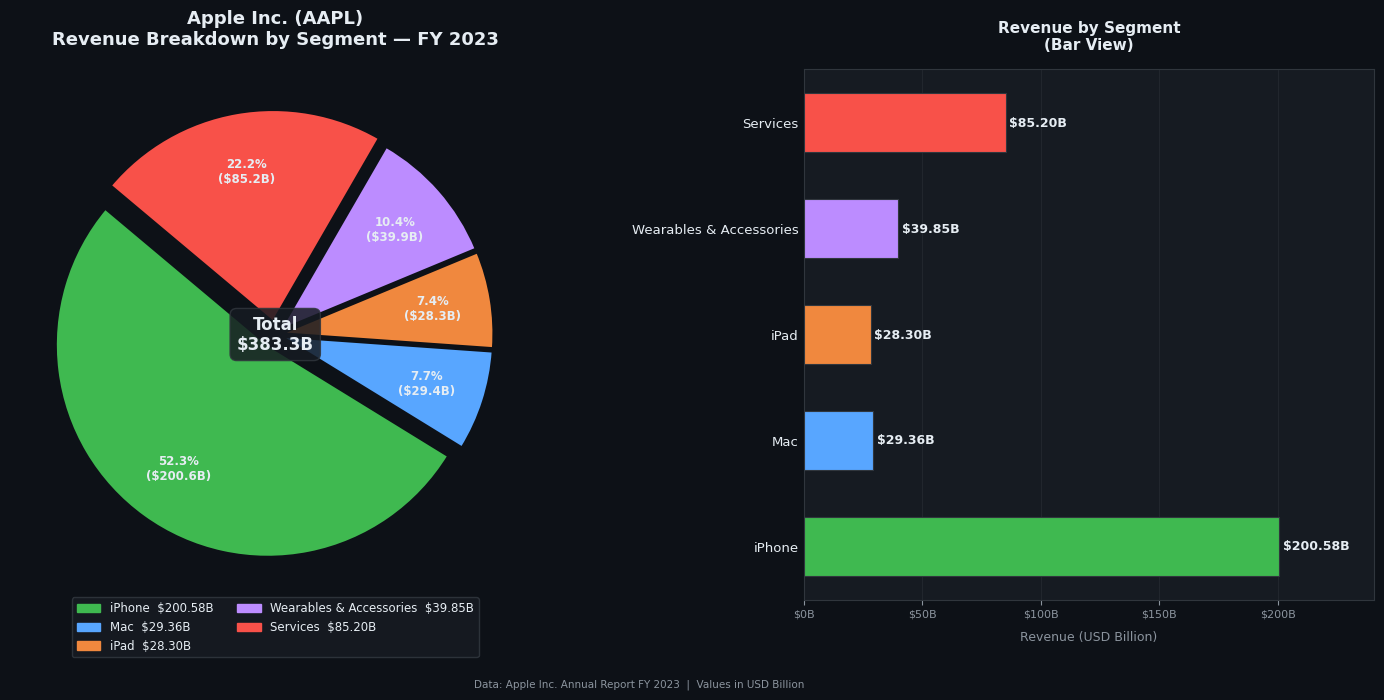

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Apple Inc. (AAPL) – Sector-wise Revenue Breakdown FY 2023 ─────────────
# Source: Apple Annual Report 2023 (approximate figures in $ Billion)

segments = [
    "iPhone",
    "Mac",
    "iPad",
    "Wearables\n& Accessories",
    "Services",
]

values = [200.58, 29.36, 28.30, 39.85, 85.20]   # in USD Billions

colors = [
    "#3fb950",   # green
    "#58a6ff",   # blue
    "#f0883e",   # orange
    "#bc8cff",   # purple
    "#f85149",   # red
]

explode = [0.06, 0.03, 0.03, 0.03, 0.06]        # pull iPhone & Services out

# ── Figure ─────────────────────────────────────────────────────────────────
fig, (ax_pie, ax_bar) = plt.subplots(
    1, 2, figsize=(15, 7),
    gridspec_kw={"width_ratios": [1.3, 1]}
)
fig.patch.set_facecolor("#0d1117")
ax_pie.set_facecolor("#0d1117")
ax_bar.set_facecolor("#161b22")

# ══════════════════════════════════════════════════════════════════════════
# LEFT – Pie chart
# ══════════════════════════════════════════════════════════════════════════
total = sum(values)

wedges, texts, autotexts = ax_pie.pie(
    values,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%\n(${pct/100*total:.1f}B)",
    startangle=140,
    explode=explode,
    colors=colors,
    wedgeprops=dict(linewidth=1.8, edgecolor="#0d1117"),
    pctdistance=0.72,
    shadow=False,
)

# Style the percentage / value labels inside slices
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_fontweight("bold")
    at.set_color("#e6edf3")

# Centre donut-style label
ax_pie.text(0, 0, f"Total\n${total:.1f}B",
            ha="center", va="center",
            fontsize=12, fontweight="bold", color="#e6edf3",
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="#161b22", edgecolor="#30363d", alpha=0.85))

ax_pie.set_title(
    "Apple Inc. (AAPL)\nRevenue Breakdown by Segment — FY 2023",
    fontsize=13, fontweight="bold", color="#e6edf3", pad=18
)

# Legend
legend_handles = [
    mpatches.Patch(color=c, label=f"{s.replace(chr(10),' ')}  ${v:.2f}B")
    for s, v, c in zip(segments, values, colors)
]
ax_pie.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=8.5,
    facecolor="#161b22",
    edgecolor="#30363d",
    labelcolor="#e6edf3",
    framealpha=0.9,
)

# ══════════════════════════════════════════════════════════════════════════
# RIGHT – Horizontal bar chart (companion view)
# ══════════════════════════════════════════════════════════════════════════
y = np.arange(len(segments))
clean_labels = [s.replace("\n", " ") for s in segments]

bars = ax_bar.barh(y, values, color=colors,
                   edgecolor="#30363d", linewidth=0.8, height=0.55, zorder=3)

# Value labels at end of each bar
for bar, val in zip(bars, values):
    ax_bar.text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"${val:.2f}B",
        va="center", ha="left",
        fontsize=9, fontweight="bold", color="#e6edf3"
    )

ax_bar.set_yticks(y)
ax_bar.set_yticklabels(clean_labels, fontsize=9.5, color="#e6edf3")
ax_bar.set_xlabel("Revenue (USD Billion)", fontsize=9, color="#8b949e", labelpad=8)
ax_bar.set_title("Revenue by Segment\n(Bar View)", fontsize=11,
                 fontweight="bold", color="#e6edf3", pad=14)

ax_bar.set_xlim(0, max(values) + 40)
ax_bar.tick_params(axis="x", colors="#8b949e", labelsize=8)
ax_bar.tick_params(axis="y", length=0)
ax_bar.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"${v:.0f}B")
)

for spine in ax_bar.spines.values():
    spine.set_edgecolor("#30363d")

ax_bar.grid(axis="x", color="#21262d", linewidth=0.8, zorder=0)

# ── Footnote ───────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.01,
    "Data: Apple Inc. Annual Report FY 2023  |  Values in USD Billion",
    ha="center", fontsize=7.5, color="#8b949e"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("D:\\Downloads\\stock_piechart.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Chart saved → stock_piechart.png")
plt.show()

Chart saved → stock_histogram.png


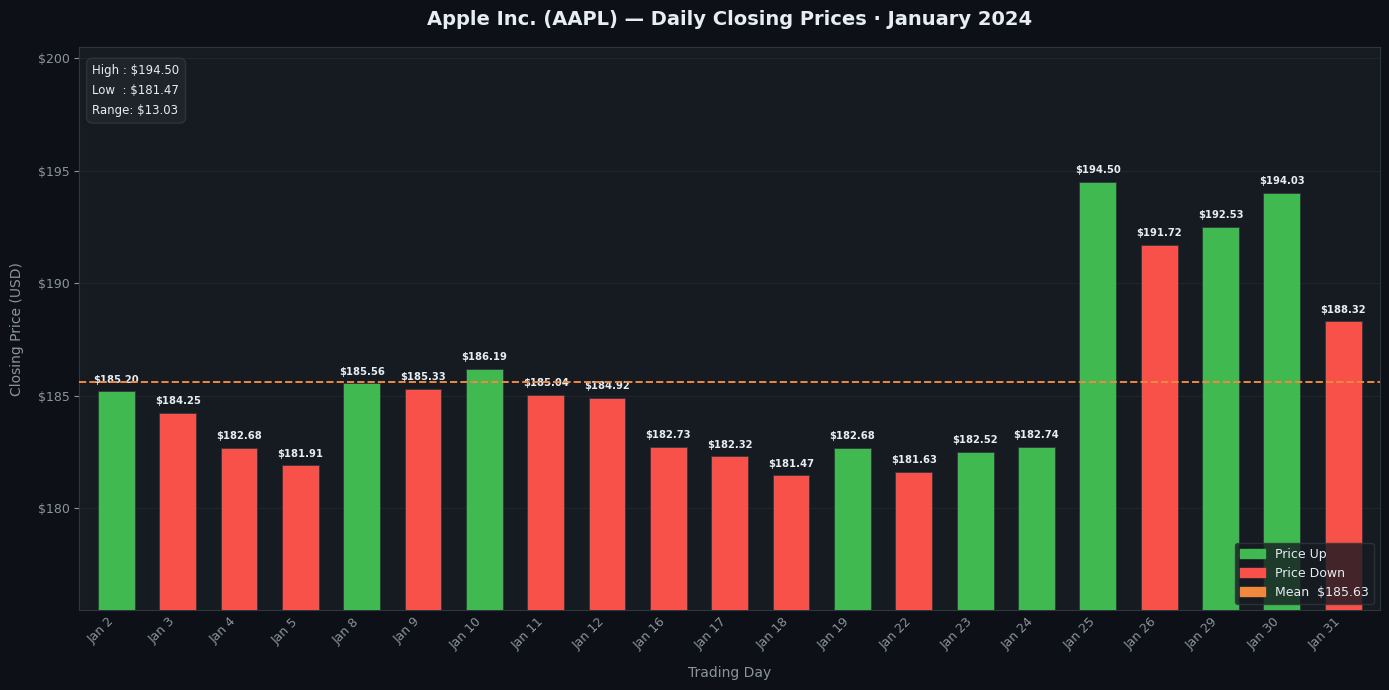

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Sample: Apple Inc. (AAPL) daily closing prices – Jan 2024 ──────────────
dates = [
    "Jan 2", "Jan 3", "Jan 4", "Jan 5", "Jan 8",
    "Jan 9", "Jan 10", "Jan 11", "Jan 12", "Jan 16",
    "Jan 17", "Jan 18", "Jan 19", "Jan 22", "Jan 23",
    "Jan 24", "Jan 25", "Jan 26", "Jan 29", "Jan 30",
    "Jan 31",
]

prices = [
    185.20, 184.25, 182.68, 181.91, 185.56,
    185.33, 186.19, 185.04, 184.92, 182.73,
    182.32, 181.47, 182.68, 181.63, 182.52,
    182.74, 194.50, 191.72, 192.53, 194.03,
    188.32,
]

# ── Figure layout ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")

# ── Bar colours: green if price rose, red if it fell ──────────────────────
colors = []
for i, p in enumerate(prices):
    if i == 0:
        colors.append("#3fb950")          # first bar → green by default
    elif p >= prices[i - 1]:
        colors.append("#3fb950")          # up  → green
    else:
        colors.append("#f85149")          # down → red

x = np.arange(len(dates))
bars = ax.bar(x, prices, color=colors, width=0.6,
              edgecolor="#30363d", linewidth=0.6, zorder=3)

# ── Value labels on top of every bar ──────────────────────────────────────
for bar, price in zip(bars, prices):
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x centre
        bar.get_height() + 0.30,              # just above the bar
        f"${price:.2f}",
        ha="center", va="bottom",
        fontsize=7.2, fontweight="bold",
        color="#e6edf3",
    )

# ── Reference line: mean price ─────────────────────────────────────────────
mean_price = np.mean(prices)
ax.axhline(mean_price, color="#f0883e", linewidth=1.4,
           linestyle="--", zorder=4, label=f"Mean  ${mean_price:.2f}")

# ── Axes styling ───────────────────────────────────────────────────────────
ax.set_xlim(-0.6, len(dates) - 0.4)
ax.set_ylim(min(prices) - 6, max(prices) + 6)

ax.set_xticks(x)
ax.set_xticklabels(dates, rotation=45, ha="right",
                   fontsize=9, color="#8b949e")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.0f}"))
ax.tick_params(axis="y", colors="#8b949e", labelsize=9)
ax.tick_params(axis="x", length=0)

for spine in ax.spines.values():
    spine.set_edgecolor("#30363d")

ax.grid(axis="y", color="#21262d", linewidth=0.8, zorder=0)

# ── Titles & labels ────────────────────────────────────────────────────────
ax.set_title("Apple Inc. (AAPL) — Daily Closing Prices · January 2024",
             fontsize=14, fontweight="bold", color="#e6edf3", pad=16)
ax.set_xlabel("Trading Day", fontsize=10, color="#8b949e", labelpad=10)
ax.set_ylabel("Closing Price (USD)", fontsize=10, color="#8b949e", labelpad=10)

# ── Legend ─────────────────────────────────────────────────────────────────
up_patch   = mpatches.Patch(color="#3fb950", label="Price Up")
down_patch = mpatches.Patch(color="#f85149", label="Price Down")
mean_line  = mpatches.Patch(color="#f0883e", label=f"Mean  ${mean_price:.2f}")

ax.legend(handles=[up_patch, down_patch, mean_line],
          loc="lower right", fontsize=9,
          facecolor="#161b22", edgecolor="#30363d",
          labelcolor="#e6edf3")

# ── Summary stats (text box) ───────────────────────────────────────────────
stats = (
    f"High : ${max(prices):.2f}\n"
    f"Low  : ${min(prices):.2f}\n"
    f"Range: ${max(prices)-min(prices):.2f}"
)
ax.text(0.01, 0.97, stats,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=8.5, color="#e6edf3",
        linespacing=1.7,
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="#21262d", edgecolor="#30363d", alpha=0.9))

plt.tight_layout()
plt.savefig("D:\\Downloads\\stock_histogram.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Chart saved → stock_histogram.png")
plt.show()


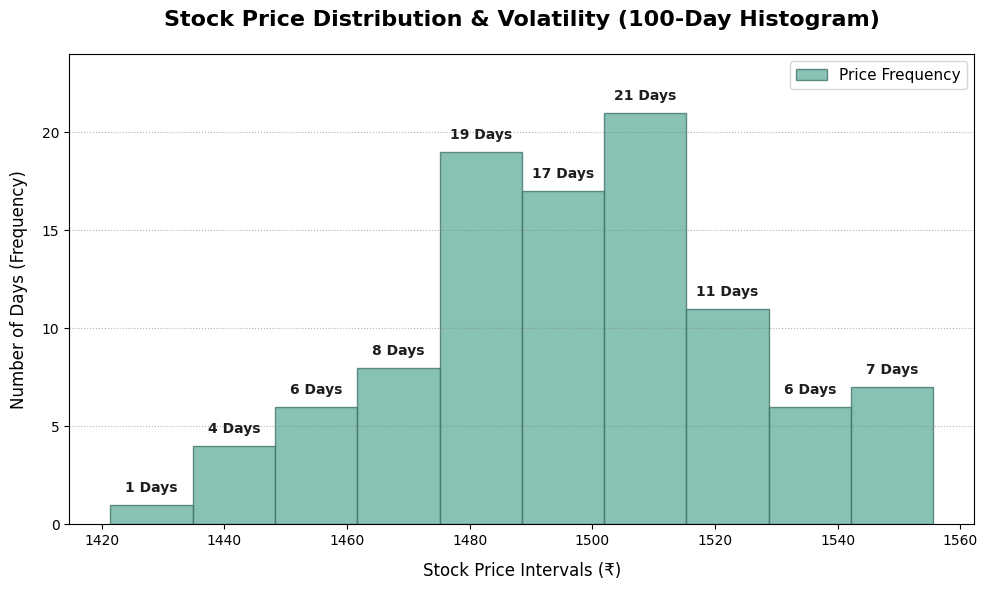

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Simulate Stock Data (e.g., 100 days of a volatile stock trading around ₹1500)
np.random.seed(42)
stock_prices = np.random.normal(loc=1500, scale=30, size=100) 

# 2. Initialize the plot
plt.figure(figsize=(10, 6))

# 3. Create the Histogram
# 'bins' defines how many intervals we break the data into
counts, bins, patches = plt.hist(stock_prices, 
                                 bins=10, 
                                 color='#69b3a2', 
                                 edgecolor='#43746a', 
                                 alpha=0.8, 
                                 label='Price Frequency')

# 4. Loop to show the frequency count value on top of every single bin
for patch in patches:
    height = patch.get_height()
    if height > 0: # Only label bins that actually have data points in them
        plt.text(patch.get_x() + patch.get_width()/2.0,   # X coordinate: center of the bin
                 height + 0.5,                            # Y coordinate: just above the bin top
                 f'{int(height)} Days',                   # Text formatting
                 ha='center',                             # Horizontal alignment
                 va='bottom',                             # Vertical alignment
                 fontsize=10,
                 fontweight='bold',
                 color='#1e1e1e')

# 5. Styling and Customization
plt.title("Stock Price Distribution & Volatility (100-Day Histogram)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Stock Price Intervals (₹)", fontsize=12, labelpad=10)
plt.ylabel("Number of Days (Frequency)", fontsize=12, labelpad=10)

# Add a clean horizontal grid to track frequencies easily
plt.grid(True, axis='y', linestyle=':', alpha=0.6, color='gray')

# Make the Y-axis limit slightly taller than the highest bin to make room for labels
plt.ylim(0, max(counts) + 3)

# Add the legend
plt.legend(loc='upper right', fontsize=11)

# 6. Display the chart smoothly
plt.tight_layout()
plt.show()

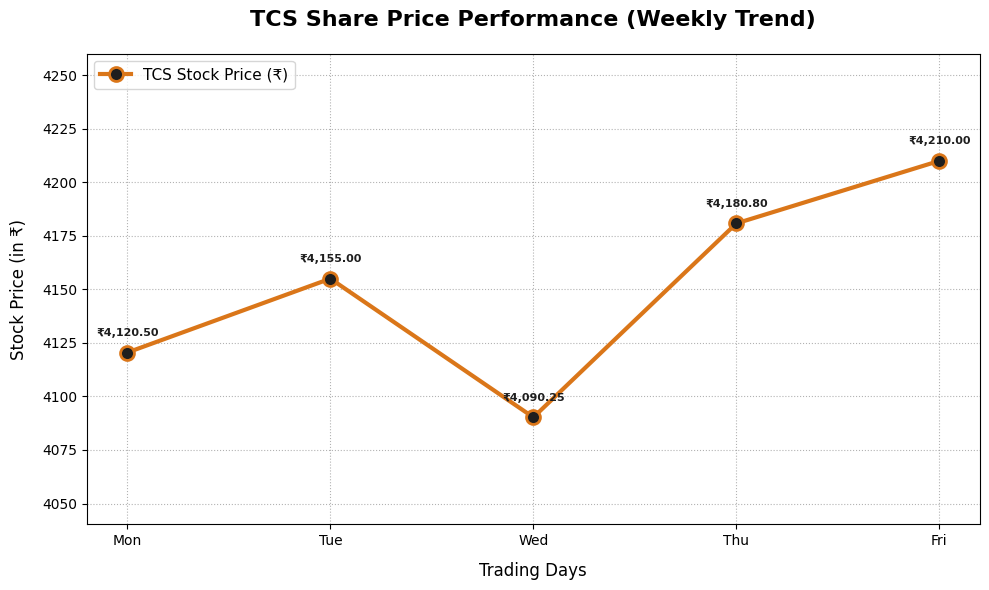

In [12]:
import matplotlib.pyplot as plt

# 1. Prepare Stock Data (Simulating TCS stock over a week)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
stock_prices = [4120.50, 4155.00, 4090.25, 4180.80, 4210.00]

# 2. Initialize the plot
plt.figure(figsize=(10, 6))

# 3. Plot the line chart
plt.plot(days, stock_prices, 
         color="#da7619",       # Emerald green commonly used for positive stock trends
         linestyle='-',         # Solid line
         linewidth=3,           # Thick line for easy viewing
         marker='o',            # Round markers at each day
         markersize=10,         # Large markers
         markerfacecolor='#1e1e1e', # Dark center for the marker
         markeredgewidth=2,     # Border width for the marker
         label='TCS Stock Price (₹)')

# 4. Loop to show values at *every single point*
for i, price in enumerate(stock_prices):
    plt.annotate(f"₹{price:,.2f}", 
                 (days[i], stock_prices[i]), 
                 textcoords="offset points", 
                 xytext=(0, 12),       # Places text 12 points directly above the marker
                 ha='center',          # Centers text horizontally over the marker
                 fontsize=8, 
                 fontweight='bold',
                 color='#1e1e1e')      # Clean dark font for readability

# 5. Styling the Dashboard
plt.title("TCS Share Price Performance (Weekly Trend)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Trading Days", fontsize=12, labelpad=10)
plt.ylabel("Stock Price (in ₹)", fontsize=12, labelpad=10)

# Expand the y-axis limits slightly so the top annotations don't cut off
plt.ylim(min(stock_prices) - 50, max(stock_prices) + 50)

# Add a subtle grid
plt.grid(True, linestyle=':', alpha=0.6, color='gray')

# Add the legend
plt.legend(loc='upper left', fontsize=11)

# 6. Smooth rendering display
plt.tight_layout()
plt.show()

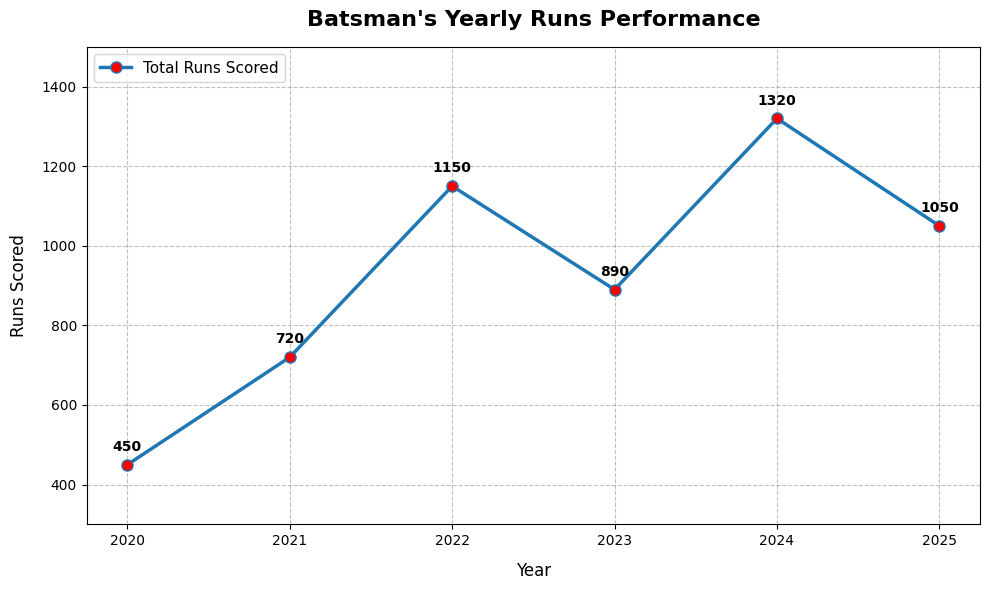

In [3]:
import matplotlib.pyplot as plt

# 1. Prepare the Data
years = [2020, 2021, 2022, 2023, 2024, 2025]
runs = [450, 720, 1150, 890, 1320, 1050]

# 2. Initialize the plot with a clean, professional size
plt.figure(figsize=(10, 6))

# 3. Plot the line chart
# 'marker=o' adds circles at data points, 'ls=-' makes it a solid line
plt.plot(years, runs, 
         color='#1f77b4',       # Clean cricket-jersey blue
         linestyle='-',         # Solid line
         linewidth=2.5,         # Thicker line for visibility
         marker='o',            # Circle markers
         markersize=8,          # Distinct marker size
         markerfacecolor='red', # Red markers to resemble a cricket ball
         label='Total Runs Scored')

# 4. Add data labels on top of each marker
for i, txt in enumerate(runs):
    plt.annotate(f"{txt}", 
                 (years[i], runs[i]), 
                 textcoords="offset points", 
                 xytext=(0,10),        # 10 points text offset above the marker
                 ha='center',          # Center horizontally
                 fontsize=10, 
                 fontweight='bold')

# 5. Labels, Title, and Aesthetics
plt.title("Batsman's Yearly Runs Performance", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("Runs Scored", fontsize=12, labelpad=10)

# Customize the axes ticks to only show our specific years
plt.xticks(years)

# Set the y-axis range slightly higher than max runs to leave room for the top label
plt.ylim(300, 1500)

# Add a subtle grid background
plt.grid(True, linestyle='--', alpha=0.5, color='gray')

# Add a legend
plt.legend(loc='upper left', fontsize=11)

# 6. Display the chart smoothly
plt.tight_layout()
plt.show()

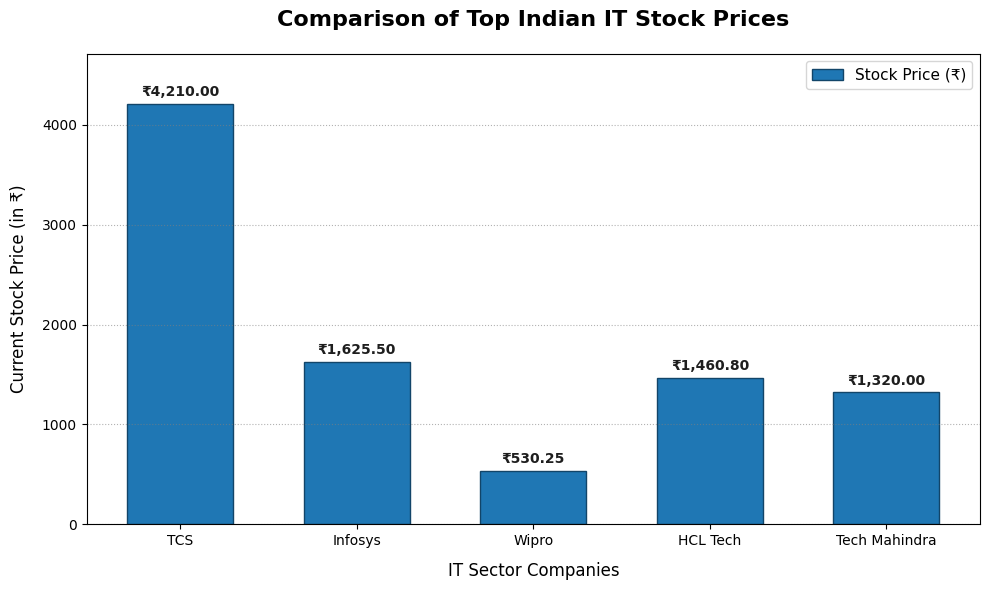

In [13]:
import matplotlib.pyplot as plt

# 1. Prepare Stock Data (Closing prices in ₹ for top Indian IT stocks)
stocks = ['TCS', 'Infosys', 'Wipro', 'HCL Tech', 'Tech Mahindra']
stock_prices = [4210.00, 1625.50, 530.25, 1460.80, 1320.00]

# 2. Initialize the plot
plt.figure(figsize=(10, 6))

# 3. Create the Bar Chart
# 'color' applies a nice corporate blue palette, 'edgecolor' cleans up the borders
bars = plt.bar(stocks, stock_prices, 
               color='#1f77b4', 
               edgecolor='#124569', 
               width=0.6,
               label='Stock Price (₹)')

# 4. Loop to show values at *every single point* (on top of each bar)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0,  # X coordinate: center of the bar
             yval + 50,                          # Y coordinate: slightly above the top of the bar
             f"₹{yval:,.2f}",                    # Formatted text string
             ha='center',                        # Horizontal alignment
             va='bottom',                        # Vertical alignment
             fontsize=10, 
             fontweight='bold',
             color='#1e1e1e')

# 5. Styling and Customization
plt.title("Comparison of Top Indian IT Stock Prices", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("IT Sector Companies", fontsize=12, labelpad=10)
plt.ylabel("Current Stock Price (in ₹)", fontsize=12, labelpad=10)

# Set the y-axis range higher than the maximum price to make room for the highest text label
plt.ylim(0, max(stock_prices) + 500)

# Add a subtle horizontal grid (axis='y' ensures lines don't run vertically through the bars)
plt.grid(True, axis='y', linestyle=':', alpha=0.6, color='gray')

# Add the legend
plt.legend(loc='upper right', fontsize=11)

# 6. Adjust layout and show the chart
plt.tight_layout()
plt.show()

Matplotlib is building the font cache; this may take a moment.


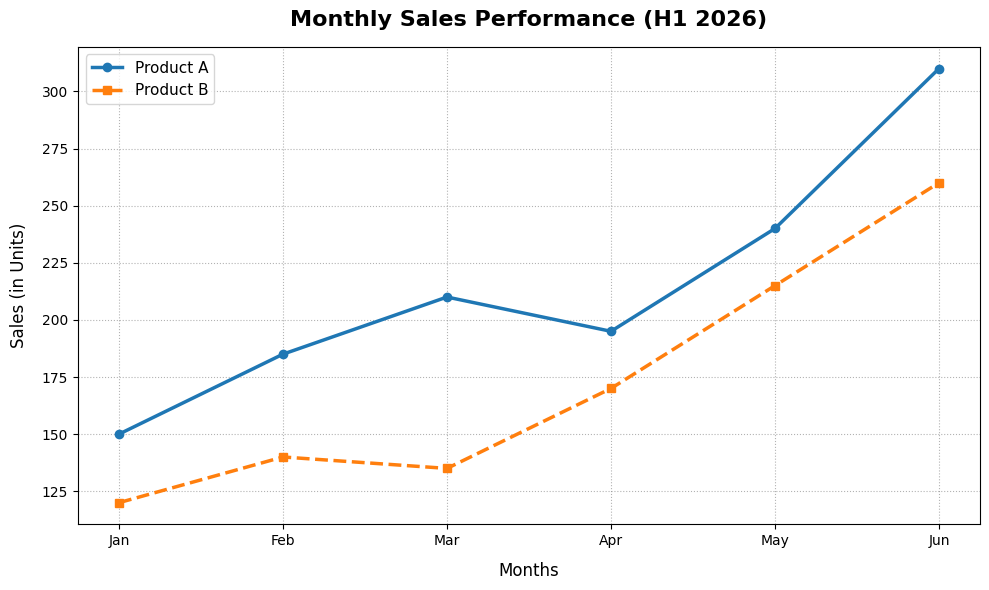

In [2]:
import matplotlib.pyplot as plt

# 1. Prepare the data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
product_a_sales = [150, 185, 210, 195, 240, 310]
product_b_sales = [120, 140, 135, 170, 215, 260]

# 2. Create the figure and plot the data
plt.figure(figsize=(10, 6))  # Sets the window width and height in inches

# Plot Product A (Solid blue line with circle markers)
plt.plot(months, product_a_sales, 
         label='Product A', 
         color='#1f77b4', 
         linestyle='-', 
         marker='o', 
         linewidth=2.5)

# Plot Product B (Dashed orange line with square markers)
plt.plot(months, product_b_sales, 
         label='Product B', 
         color='#ff7f0e', 
         linestyle='--', 
         marker='s', 
         linewidth=2.5)

# 3. Add styling and labels
plt.title('Monthly Sales Performance (H1 2026)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Months', fontsize=12, labelpad=10)
plt.ylabel('Sales (in Units)', fontsize=12, labelpad=10)

# Add a grid to make the values easier to read
plt.grid(True, linestyle=':', alpha=0.6, color='gray')

# Add a legend to identify the lines
plt.legend(fontsize=11, loc='upper left')

# 4. Display the chart
plt.tight_layout()  # Adjusts spacing so labels don't get cut off
plt.show()